# IMPORT LIBRARIES #

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD THE DATASET #


In [2]:
data = pd.read_excel("/content/drive/MyDrive/HousePricePrediction.xlsx")

In [3]:
print(data.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [4]:
data.shape

(2919, 13)

In [6]:
data.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [8]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1


# DATA CLEANING #

In [10]:
data.drop(['Id'],axis=1,inplace=True)

In [11]:
data['SalePrice']=data['SalePrice'].fillna(data['SalePrice'].mean())

In [12]:
new_data=data.dropna()
print(new_data.isnull().sum())

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64


# DATA PREPROCESSING #

In [14]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

Categorical variables: 4
Integer variables: 5
Float variables: 3


# EXPLORATORY DATA ANALYSIS #

<Axes: >

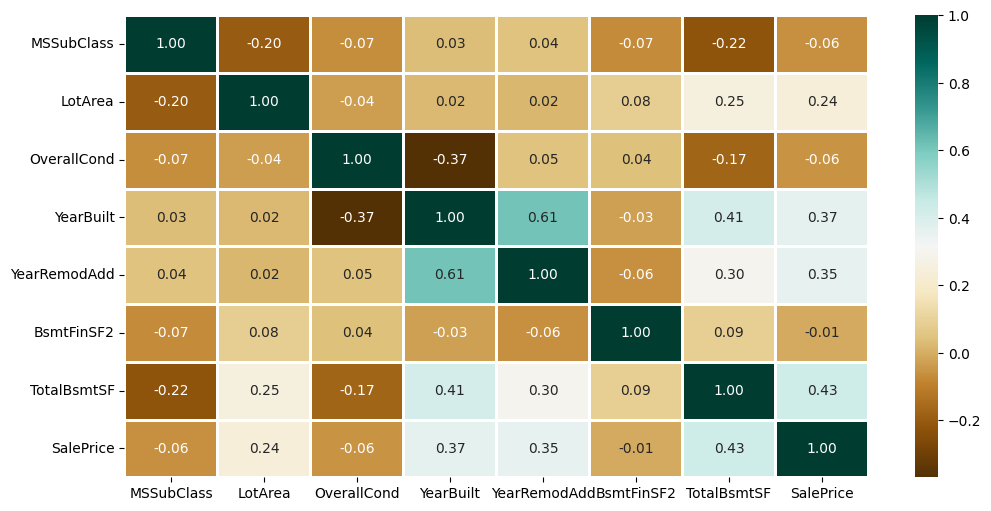

In [15]:
numerical_dataset = data.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap = 'BrBG',
            fmt = '.2f',
            linewidths = 2,
            annot = True)

<Axes: title={'center': 'No. Unique values of Categorical Features'}>

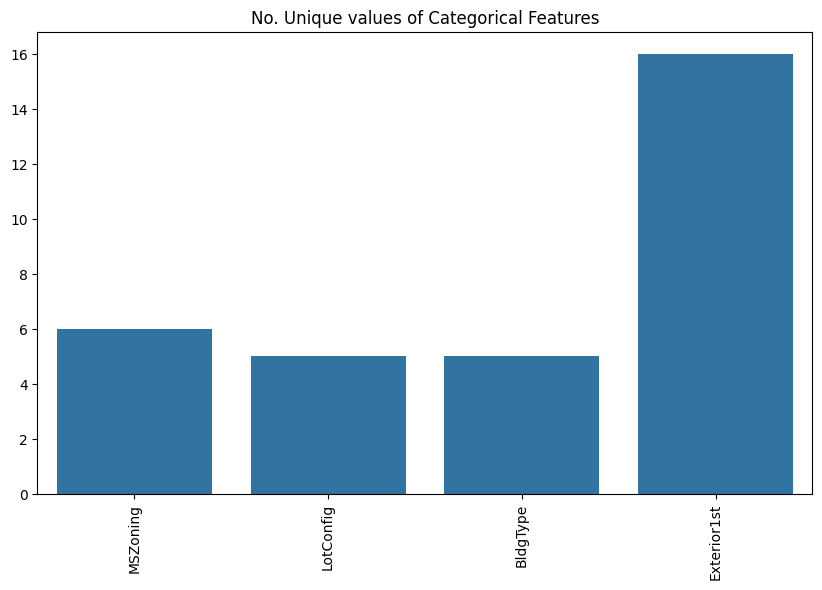

In [18]:
unique_values = []
for col in object_cols:
  unique_values.append(data[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

# LABEL ENCODING #

In [25]:
from sklearn.preprocessing import OneHotEncoder

s = (new_data.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ',
      len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [28]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_data[object_cols]))
OH_cols.index = new_data.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_data.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)


print(df_final.head())

   MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodAdd  BsmtFinSF2  \
0          60     8450            5       2003          2003         0.0   
1          20     9600            8       1976          1976         0.0   
2          60    11250            5       2001          2002         0.0   
3          70     9550            5       1915          1970         0.0   
4          60    14260            5       2000          2000         0.0   

   TotalBsmtSF  SalePrice  MSZoning_C (all)  MSZoning_FV  ...  \
0        856.0   208500.0               0.0          0.0  ...   
1       1262.0   181500.0               0.0          0.0  ...   
2        920.0   223500.0               0.0          0.0  ...   
3        756.0   140000.0               0.0          0.0  ...   
4       1145.0   250000.0               0.0          0.0  ...   

   Exterior1st_CemntBd  Exterior1st_HdBoard  Exterior1st_ImStucc  \
0                  0.0                  0.0                  0.0   
1               

#TRAIN DATA AND TEST DATA SPLIT

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0)

# MODEL SELECTION #

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)

mean_absolute_percentage_error(Y_valid, Y_pred)

0.19705391074213768

# VALIDATE THE MODEL #

In [32]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_valid, Y_pred))

Mean Absolute Error: 32513.14777044417


In [35]:
import pickle

with open('model.pkl','wb') as files:
    pickle.dump(model_RFR,files)

In [36]:
import pickle

with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [42]:
prediction = loaded_model.predict(X_valid)
print(prediction)

[188168.47835616 340018.95876712 175336.95671233 165660.59794521
 213360.59794521 185236.95671233 152842.71753425 147718.47835616
 180952.71753425 214330.59794521 162732.71753425 214532.11958904
 177429.07630137 152450.59794521 200668.47835616 160060.59794521
 141442.51958904 181300.59794521 245249.21958904 175310.59794521
 182310.59794521 159344.83712329 200908.49794521 167594.83712329
 140126.35876712 175118.47835616 163122.43712329 134024.23917808
 170210.59794521 178829.07630137 161379.23917808 183934.59794521
 180379.07630137 166908.47835616 177770.59794521 181552.71753425
 157202.71753425 170486.95671233 167258.47835616 187392.71753425
 220028.47835616 209103.83712329 186829.07630137 130349.57835616
 181782.23917808 211894.83712329 181329.07630137 131436.35876712
 165752.71753425 184234.83712329 199098.81753425 183651.35876712
 195138.83712329 137626.35876712 193492.71753425 163244.83712329
 164836.95671233 192929.07630137 164433.632379   199300.59794521
 207160.59794521 140088.8